# Churn Prediction with Budget-Constrained Retention Optimization

## Business problem

Most churn projects stop at one question: *"which customers are likely to leave?"*
That question alone is not very useful to a business, because a company can almost never
afford to intervene on every customer flagged as high-risk — retention offers (discounts,
free upgrades, account manager calls) cost money.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)


pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

DATA_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
RANDOM_STATE = 42


## 1. Load and inspect the data

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Data cleaning

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing TotalCharges after conversion:", df['TotalCharges'].isna().sum())

# These are all tenure==0 customers (brand new) -> their total charges to date is genuinely 0
df.loc[df['TotalCharges'].isna(), 'TotalCharges'] = 0

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

customer_ids = df['customerID']
df = df.drop(columns=['customerID'])
df.head()


Missing TotalCharges after conversion: 11


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 3. Exploratory data analysis

Before modelling, we check the overall churn rate (this matters later — it tells us whether
we are dealing with class imbalance and need to account for it), and look at which factors
visibly correlate with churn.


Overall churn rate: 26.5%


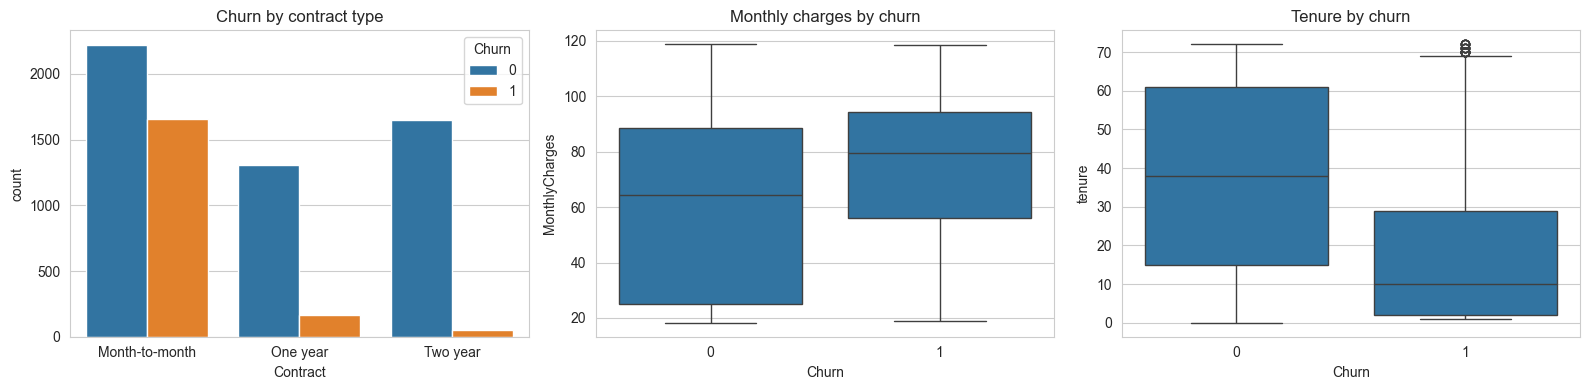

In [5]:
churn_rate = df['Churn'].mean()
print(f"Overall churn rate: {churn_rate:.1%}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[0])
axes[0].set_title('Churn by contract type')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[1])
axes[1].set_title('Monthly charges by churn')

sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[2])
axes[2].set_title('Tenure by churn')

plt.tight_layout()
plt.show()


## 4. Feature engineering and train/test split

We split the data **before** fitting any encoders or scalers, and wrap preprocessing in a
`ColumnTransformer` + `Pipeline`. This avoids data leakage — a mistake I've seen described as
one of the most common invisible bugs in fresher churn projects (e.g. computing category
frequencies or scaling using the full dataset before splitting).


In [6]:
target = 'Churn'
X = df.drop(columns=[target])
y = df[target]

categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols = X.select_dtypes(exclude='object').columns.tolist()
print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, customer_ids, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])


Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


## 5. Model training

We train two models:

- **Logistic Regression** — a transparent baseline. If a complex model can't beat this by a
  meaningful margin, the complexity isn't earning its place.
- **Random Forest** — the main model, with `class_weight='balanced'` to account for the
  churn class being the minority class (roughly 1 in 4-5 customers churns in this dataset,
  so a model that just predicts "No churn" for everyone would already score ~73-80% accuracy
  — which is exactly why accuracy alone is not the metric we report).

Both are wrapped in the same preprocessing pipeline so there's no risk of mismatched
encoding between train and test.


In [7]:
log_reg = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])
log_reg.fit(X_train, y_train)

rf = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, max_depth=8,
                                      class_weight='balanced', random_state=RANDOM_STATE))
])
rf.fit(X_train, y_train)
print("Models trained.")


Models trained.


## 6. Evaluation — beyond accuracy

In [8]:
results = {}
for name, model in [('Logistic Regression', log_reg), ('Random Forest', rf)]:
    proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    results[name] = auc
    print(f"{name}: ROC-AUC = {auc:.3f}")
    print(classification_report(y_test, model.predict(X_test), target_names=['No churn', 'Churn']))
    print("-" * 60)


Logistic Regression: ROC-AUC = 0.846
              precision    recall  f1-score   support

    No churn       0.91      0.73      0.81      1294
       Churn       0.52      0.80      0.63       467

    accuracy                           0.75      1761
   macro avg       0.71      0.76      0.72      1761
weighted avg       0.81      0.75      0.76      1761

------------------------------------------------------------
Random Forest: ROC-AUC = 0.844
              precision    recall  f1-score   support

    No churn       0.91      0.76      0.83      1294
       Churn       0.54      0.78      0.64       467

    accuracy                           0.76      1761
   macro avg       0.72      0.77      0.73      1761
weighted avg       0.81      0.76      0.78      1761

------------------------------------------------------------


Selected model for the rest of the notebook: Logistic Regression


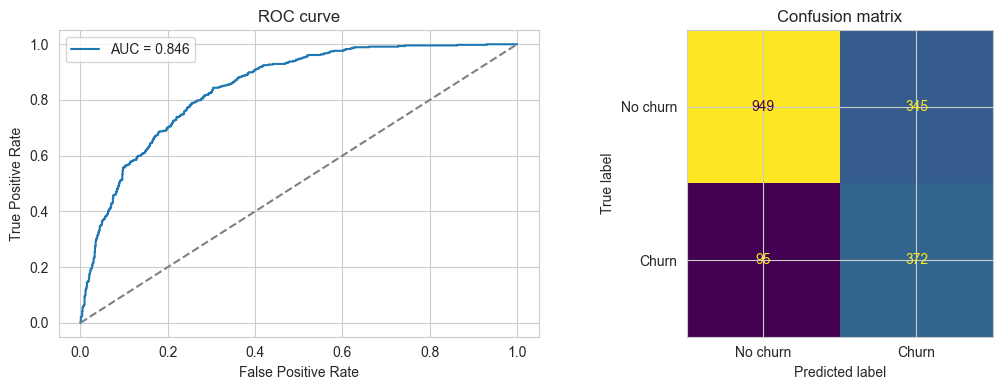

In [9]:
best_model_name = max(results, key=results.get)
best_model = rf if best_model_name == 'Random Forest' else log_reg
print("Selected model for the rest of the notebook:", best_model_name)

proba_test = best_model.predict_proba(X_test)[:, 1]
preds_test = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[0].plot(fpr, tpr, label=f"AUC = {results[best_model_name]:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC curve')
axes[0].legend()

cm = confusion_matrix(y_test, preds_test)
ConfusionMatrixDisplay(cm, display_labels=['No churn', 'Churn']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Confusion matrix')

plt.tight_layout()
plt.show()


## 7. Estimating Customer Lifetime Value (CLV)
```
expected_remaining_months = min(1 / max(churn_probability, 0.02), 36)   # capped at 3 years
CLV = MonthlyCharges * expected_remaining_months
```

In [10]:
test_df = X_test.copy()
test_df['customerID'] = id_test.values
test_df['actual_churn'] = y_test.values
test_df['churn_probability'] = proba_test

capped_prob = test_df['churn_probability'].clip(lower=0.02)
test_df['expected_remaining_months'] = np.minimum(1 / capped_prob, 36)
test_df['CLV'] = test_df['MonthlyCharges'] * test_df['expected_remaining_months']

# Expected revenue at risk if we do nothing for this customer
test_df['expected_revenue_at_risk'] = test_df['churn_probability'] * test_df['CLV']

test_df[['customerID', 'MonthlyCharges', 'churn_probability', 'CLV', 'expected_revenue_at_risk']].sort_values(
    'expected_revenue_at_risk', ascending=False
).head(10)


,customerID,MonthlyCharges,churn_probability,CLV,expected_revenue_at_risk
4206,0017-IUDMW,116.80,0.114411,1020.884488,116.80
4627,3680-CTHUH,116.60,0.291466,400.046586,116.60
2926,0106-UGRDO,116.00,0.203291,570.611629,116.00
4600,1741-WTPON,115.85,0.119444,969.910104,115.85
526,8606-CIQUL,115.75,0.139279,831.065207,115.75
6537,1444-VVSGW,115.65,0.180489,640.758188,115.65
4737,9298-WGMRW,115.50,0.137923,837.423977,115.50
3897,8015-IHCGW,115.50,0.158700,727.790082,115.50
5819,3396-DKDEL,115.15,0.123199,934.666672,115.15
746,6919-ELBGL,114.95,0.134859,852.373547,114.95


## 8. Budget-constrained retention optimization

```
maximize   sum( value_i * x_i )
subject to sum( cost_i * x_i ) <= BUDGET
           x_i in {0, 1}
```

where `value_i` = expected revenue saved if we successfully retain customer *i*, and
`cost_i` = cost of the retention discount for customer *i*.

In [11]:
BASE_COST = 10                   # flat admin/outreach cost per targeted customer ($)
DISCOUNT_RATE = 0.08             # retention offer = 8% off monthly bill, applied on top of the base cost
INTERVENTION_SUCCESS_RATE = 0.35 # assumed fraction of targeted at-risk customers who stay after the offer
MONTHLY_BUDGET = 3000            # total amount ($) the business can spend on retention this month

opt_df = test_df.copy()
opt_df['intervention_cost'] = BASE_COST + opt_df['MonthlyCharges'] * DISCOUNT_RATE
opt_df['expected_value_if_targeted'] = (
    opt_df['churn_probability'] * INTERVENTION_SUCCESS_RATE * opt_df['CLV']
)

# Only worth considering customers the model actually flags as at-risk;
# targeting a near-zero-risk customer just burns budget for no expected benefit.
candidates = opt_df[opt_df['churn_probability'] >= 0.20].reset_index(drop=True)
print(f"Candidates worth considering for a retention offer: {len(candidates)} out of {len(opt_df)} test customers")


Candidates worth considering for a retention offer: 1149 out of 1761 test customers


In [12]:
def solve_knapsack(values, costs, max_budget):
    # Classic 0/1 knapsack via dynamic programming.
    # Returns:
    #   dp: array where dp[b] = best achievable value with budget exactly <= b
    #   keep: boolean matrix (n_items x max_budget+1) recording whether item i
    #         was taken in the optimal solution for each budget level b
    # Costs must be non-negative integers (we round to the nearest dollar).
    n = len(values)
    dp = np.zeros(max_budget + 1)
    keep = np.zeros((n, max_budget + 1), dtype=bool)

    for i in range(n):
        cost_i = costs[i]
        val_i = values[i]
        prev = dp.copy()
        if cost_i <= max_budget:
            shifted = np.full_like(dp, -np.inf)
            shifted[cost_i:] = prev[:max_budget + 1 - cost_i] + val_i
            take = shifted > prev
            dp = np.where(take, shifted, prev)
            keep[i] = take
    return dp, keep


def recover_selection(keep, budget):
    # Backtrack through the DP choice table to recover which items were selected.
    n = keep.shape[0]
    selected = np.zeros(n, dtype=int)
    b = budget
    for i in range(n - 1, -1, -1):
        if keep[i, b]:
            selected[i] = 1
            b -= costs_int[i]
    return selected


costs_int = np.round(candidates['intervention_cost'].values).astype(int)
values_arr = candidates['expected_value_if_targeted'].values

dp_table, keep_table = solve_knapsack(values_arr, costs_int, MONTHLY_BUDGET)
candidates['selected_optimized'] = recover_selection(keep_table, MONTHLY_BUDGET)

optimized_value = (candidates['expected_value_if_targeted'] * candidates['selected_optimized']).sum()
# Use the same rounded-to-dollar costs the DP actually optimized against, so the reported
# spend never appears to exceed the budget due to rounding drift against the raw float costs.
optimized_cost = (costs_int * candidates['selected_optimized']).sum()
optimized_count = candidates['selected_optimized'].sum()

print(f"Optimized selection: {optimized_count} customers targeted, "
      f"cost = ${optimized_cost:,.0f} / ${MONTHLY_BUDGET:,.0f} budget")
print(f"Optimized expected revenue saved: ${optimized_value:,.2f}")


Optimized selection: 164 customers targeted, cost = $3,000 / $3,000 budget
Optimized expected revenue saved: $6,021.77


## 9. Comparing against the naive baseline

Most fresher churn projects stop at "sort by churn probability, target the top N." We build
that exact naive baseline here and compare it head-to-head against the optimized selection,
using the **same budget**, to make the value of the optimization layer concrete and
demonstrable rather than just asserted.


In [13]:
candidates_sorted = candidates.sort_values('churn_probability', ascending=False).reset_index(drop=True)

naive_selected = []
running_cost = 0.0
for i, row in candidates_sorted.iterrows():
    if running_cost + row['intervention_cost'] <= MONTHLY_BUDGET:
        naive_selected.append(i)
        running_cost += row['intervention_cost']

naive_value = candidates_sorted.loc[naive_selected, 'expected_value_if_targeted'].sum()
naive_cost = candidates_sorted.loc[naive_selected, 'intervention_cost'].sum()
naive_count = len(naive_selected)

print(f"Naive (highest churn-probability-first) selection: {naive_count} customers targeted, "
      f"cost = ${naive_cost:,.0f} / ${MONTHLY_BUDGET:,.0f} budget")
print(f"Naive expected revenue saved: ${naive_value:,.2f}")

improvement = optimized_value - naive_value
improvement_pct = (improvement / naive_value) * 100 if naive_value > 0 else float('nan')
print(f"\nImprovement from optimization: ${improvement:,.2f} ({improvement_pct:.1f}% more expected revenue saved) "
      f"for the exact same budget.")


Naive (highest churn-probability-first) selection: 180 customers targeted, cost = $2,999 / $3,000 budget
Naive expected revenue saved: $5,244.33

Improvement from optimization: $777.44 (14.8% more expected revenue saved) for the exact same budget.


,Strategy,Customers targeted,Budget spent ($),Expected revenue saved ($)
0,Naive (top churn-probability),180,2998.704,5244.3300
1,Optimized (budget-constrained knapsack),164,3000.000,6021.7675


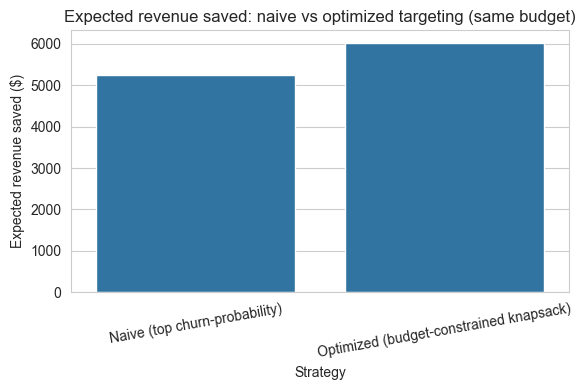

In [14]:
comparison = pd.DataFrame({
    'Strategy': ['Naive (top churn-probability)', 'Optimized (budget-constrained knapsack)'],
    'Customers targeted': [naive_count, optimized_count],
    'Budget spent ($)': [naive_cost, optimized_cost],
    'Expected revenue saved ($)': [naive_value, optimized_value]
})
display(comparison)

plt.figure(figsize=(6, 4))
sns.barplot(data=comparison, x='Strategy', y='Expected revenue saved ($)')
plt.title('Expected revenue saved: naive vs optimized targeting (same budget)')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


## 10. Budget sensitivity check

A one-off comparison at a single budget level could be a coincidence. We re-run the
optimization across a range of budgets to check that the optimized strategy consistently
beats the naive one — this is the kind of robustness check that separates a demo from an
analysis a business could actually trust.


,Budget,Optimized,Naive
0,1000,2051.8225,1787.5725
1,2000,4062.4850,3536.1200
2,3000,6021.7675,5244.3300
3,4000,7943.5475,6964.7725
4,5000,9819.9325,8662.1150
5,7500,14389.9525,12812.1525
6,10000,18714.0800,16810.0625


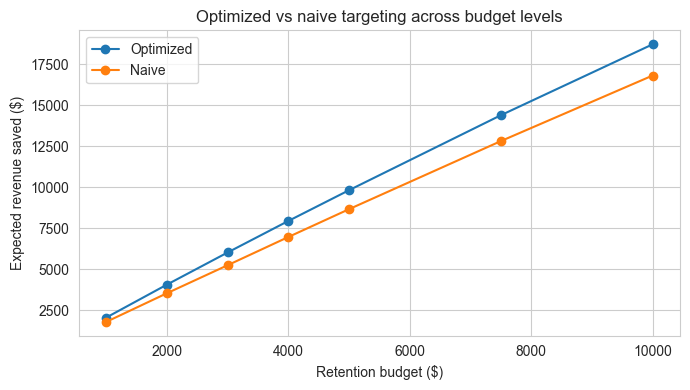

In [15]:
budgets = [1000, 2000, 3000, 4000, 5000, 7500, 10000]

max_test_budget = max(budgets)
dp_table_full, _ = solve_knapsack(values_arr, costs_int, max_test_budget)

sensitivity_rows = []
for b in budgets:
    opt_val_b = dp_table_full[b]

    # Naive: greedily spend budget on highest churn-probability customers first
    running_cost_b = 0.0
    naive_val_b = 0.0
    for _, row in candidates_sorted.iterrows():
        if running_cost_b + row['intervention_cost'] <= b:
            running_cost_b += row['intervention_cost']
            naive_val_b += row['expected_value_if_targeted']

    sensitivity_rows.append({'Budget': b, 'Optimized': opt_val_b, 'Naive': naive_val_b})

sens_df = pd.DataFrame(sensitivity_rows)
display(sens_df)

plt.figure(figsize=(7, 4))
plt.plot(sens_df['Budget'], sens_df['Optimized'], marker='o', label='Optimized')
plt.plot(sens_df['Budget'], sens_df['Naive'], marker='o', label='Naive')
plt.xlabel('Retention budget ($)')
plt.ylabel('Expected revenue saved ($)')
plt.title('Optimized vs naive targeting across budget levels')
plt.legend()
plt.tight_layout()
plt.show()


## 11. Conclusion

**What this project demonstrates:**
- A churn classifier evaluated properly for an imbalanced problem (ROC-AUC, not accuracy).
- A simple, explainable CLV estimate that turns a probability into a dollar figure.
- A genuine constrained-optimization layer (0/1 knapsack via integer programming) that
  turns predictions into an actual, budget-respecting business decision.
- A head-to-head comparison proving the optimization layer adds measurable value over the
  "just target the highest-risk customers" approach most churn projects stop at.

**How this would run in production:**
1. Score all active customers monthly with the trained pipeline.
2. Feed scores + CLV into the optimizer with that month's actual retention budget.
3. Export the selected customer list to the retention/marketing team as a target list.
4. Track actual retention outcomes on the targeted group to re-estimate
   `INTERVENTION_SUCCESS_RATE` over time, closing the feedback loop.

